# Project Milestone One: Gathering your Team, Understanding the Problem,  Exploring the Data

#### Due: Midnight on March 29th (with 2-hour grace period)  

#### There will be no late period on this homework, as we need to start manual grading immediately!



### What We Will Do in This Milestone Assignment

1. You will convene your team and fill out the Team Contract (in the Homework Repo), to be submitted to Gradescope.
2. You must select a team leader for the purpose of submitting this notebook, after the team collaborates to complete the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>link</a> describes how to add group members to your leader's submission.
3. At the conclusion of your work on this Milestone, you will complete an Individual Evaluation of your team's work (in the Homework Repo) and upload it *individually* to Gradescope.
4. We will follow a simplified version of the **Machine Learning Project Checklist** in Appendix A in our textbook *Hands-On Machine Learning* (pp.779):  

>Part 1:	Frame the problem and look at the big picture  
Part 2: Download and perform preliminary exploration of the data  
Part 3: Clean the Data: Drop, Impute, and Encode   
Part 4: Explore Feature Relationships  
Part 5: Investigate Feature Engineering options to better expose the underlying data patterns  

### The Dataset

All teams will use the same dataset. It is a smaller version of the Zillow housing dataset that was used in the
Zillow Million Dollar Prize which ran on Kaggle in 2017 (sorry, the contest is closed, so you can't win any money
with this project!).  We will try to predict the assessed tax value (`'taxvaluedollarcnt'`) of the property from a large collection
of descriptors. Some features are closely related and some are obviously useless.  There are potential outliers and also quite a few missing values.

This is a good example of a dataset which has not been predigested for you on Kaggle, and should give you a good chance to
try all the various tools in your toolbox!


In [ ]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.**

For a detailed description of the dataset features, please refer to  **Appendix 1** below.

**Note:** Do **not** perform a train/test split for this milestone (unlike HOML suggests), since you need to do the split **after** any data preparation and feature engineering. You can wait until Milestone 2 to do the split.

In [ ]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File downloaded successfully.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercizing all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data;
- Create a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:**

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?


The objective of this project is to build a predictive model that estimates the property tax assessed value (`taxvaluedollarcnt`) based on various housing and location features. From a business perspective, this helps Zillow better understand property valuation patterns, improve pricing accuracy, and support real estate decision making for buyers, sellers, and internal stakeholders such as marketing and analytics teams.

**1.2:**  How will your solution be used?


The solution will be used by Zillow’s internal teams to estimate home values more accurately and identify key factors that influence property pricing. Marketing teams can use these insights to target customers more effectively, while analysts can use the model to support pricing strategies, property comparisons, and trend analysis.

**1.3:**  How should success (or failure) be measured?


Success should be measured using regression performance metrics such as Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE), which quantify how close the predicted values are to actual property values. A successful model would minimize these errors and generalize well to unseen data.

## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process.
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [ ]:
# Load into dataframe: already done in code cell above.

# Take a look at first 5 rows
df.head()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


In [ ]:


# Print basic stats
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  f

In [ ]:
# Print number of unique values in each column
# Count NaNs because in our case it does matter to us
df.nunique(dropna=False)

,0
parcelid,77414
airconditioningtypeid,6
architecturalstyletypeid,6
basementsqft,44
bathroomcnt,23
bedroomcnt,17
buildingclasstypeid,3
buildingqualitytypeid,13
calculatedbathnbr,22
decktypeid,2


#### **2.A Discussion:** Answer the following questions.

**2.A.1:**  Which features are categorical?

In [ ]:
# Get columns with object/string dtype (true categorical)


print("The categorical columns are:")
print(df.select_dtypes(include=['object']).columns.tolist())

The categorical columns are:
['hashottuborspa', 'propertycountylandusecode', 'propertyzoningdesc', 'fireplaceflag', 'taxdelinquencyflag']


**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly.

Yes. At first glance:
- `parcelid`: unique row indentifier. produces no predictive value
- `rawcensustractandblock`: unprocessed precursor to 'censustractandblock'. Pointless having reduntant information

There are others with dubious potential for application, such as all the regional features beginning with "regionid-", but as they all have a number of unique values that is more than 2, they may be useful for local analysis. As they are unique identifiers it's unlikely they will be able to help us extrapolate knowledge of the housing market to different data, as the identifiers are not universal.
    

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example.

In [ ]:
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing_pct.round(2).to_string())

buildingclasstypeid             99.98
finishedsquarefeet13            99.95
basementsqft                    99.94
storytypeid                     99.94
yardbuildingsqft26              99.91
fireplaceflag                   99.78
architecturalstyletypeid        99.73
typeconstructiontypeid          99.71
finishedsquarefeet6             99.50
pooltypeid10                    99.40
decktypeid                      99.21
poolsizesum                     98.88
pooltypeid2                     98.62
hashottuborspa                  98.02
yardbuildingsqft17              96.92
taxdelinquencyyear              96.26
taxdelinquencyflag              96.26
finishedsquarefeet15            96.10
finishedsquarefeet50            92.22
finishedfloor1squarefeet        92.22
fireplacecnt                    89.32
threequarterbathnbr             86.98
pooltypeid7                     80.57
poolcnt                         79.16
numberofstories                 77.32
airconditioningtypeid           67.78
garagetotals

Yes, but it's not so straightforward. Some features are mostly empty (95% and above) simply because they describe variables not reflected in the vast majority of real estate properties.

For example 'hashottuborspa' has a 98.88% missing values rate, likely because 98.88% of properties don't have either facility. But those that do, are likely to notice a significant difference in property value compared to those that don't. Therefore, we can't call any of these features "useless".

On the other hand, some features don't fall under this umbrella and do seem to be useless:
- `storytypeid`, `architecturalstyletypeid` and `typeconstructiontypeid` are extremely sparce with very few unique values among what is present, which leads into our analysis below.

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example.

In [ ]:
# Get unique value counts per column, sorted ascending, counting NaNs as a unique value
print(df.nunique(dropna=False).sort_values(ascending=True))

decktypeid                          2
pooltypeid7                         2
pooltypeid2                         2
pooltypeid10                        2
poolcnt                             2
hashottuborspa                      2
taxdelinquencyflag                  2
storytypeid                         2
fireplaceflag                       2
assessmentyear                      2
buildingclasstypeid                 3
regionidcounty                      4
fips                                4
typeconstructiontypeid              5
numberofstories                     5
threequarterbathnbr                 5
architecturalstyletypeid            6
fireplacecnt                        6
airconditioningtypeid               6
unitcnt                             9
heatingorsystemtypeid              11
buildingqualitytypeid              13
propertylandusetypeid              14
taxdelinquencyyear                 14
fullbathcnt                        14
finishedsquarefeet13               14
garagecarcnt

Following the analysis of unique value counts, features such as `storytypeid`, `architecturalstyletypeid`, and `typeconstructiontypeid` have both very low uniqueness and extremely high proportions of missing values. This means that not only do they provide limited variability, but they also lack sufficient data coverage across observations. As a result, these features are unlikely to contribute meaningful predictive power to the model and may instead introduce noise. Therefore, they are strong candidates for removal during preprocessing.

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the **target and three (3)** other interesting-looking features in the dataset (i.e., a total of 4):  
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

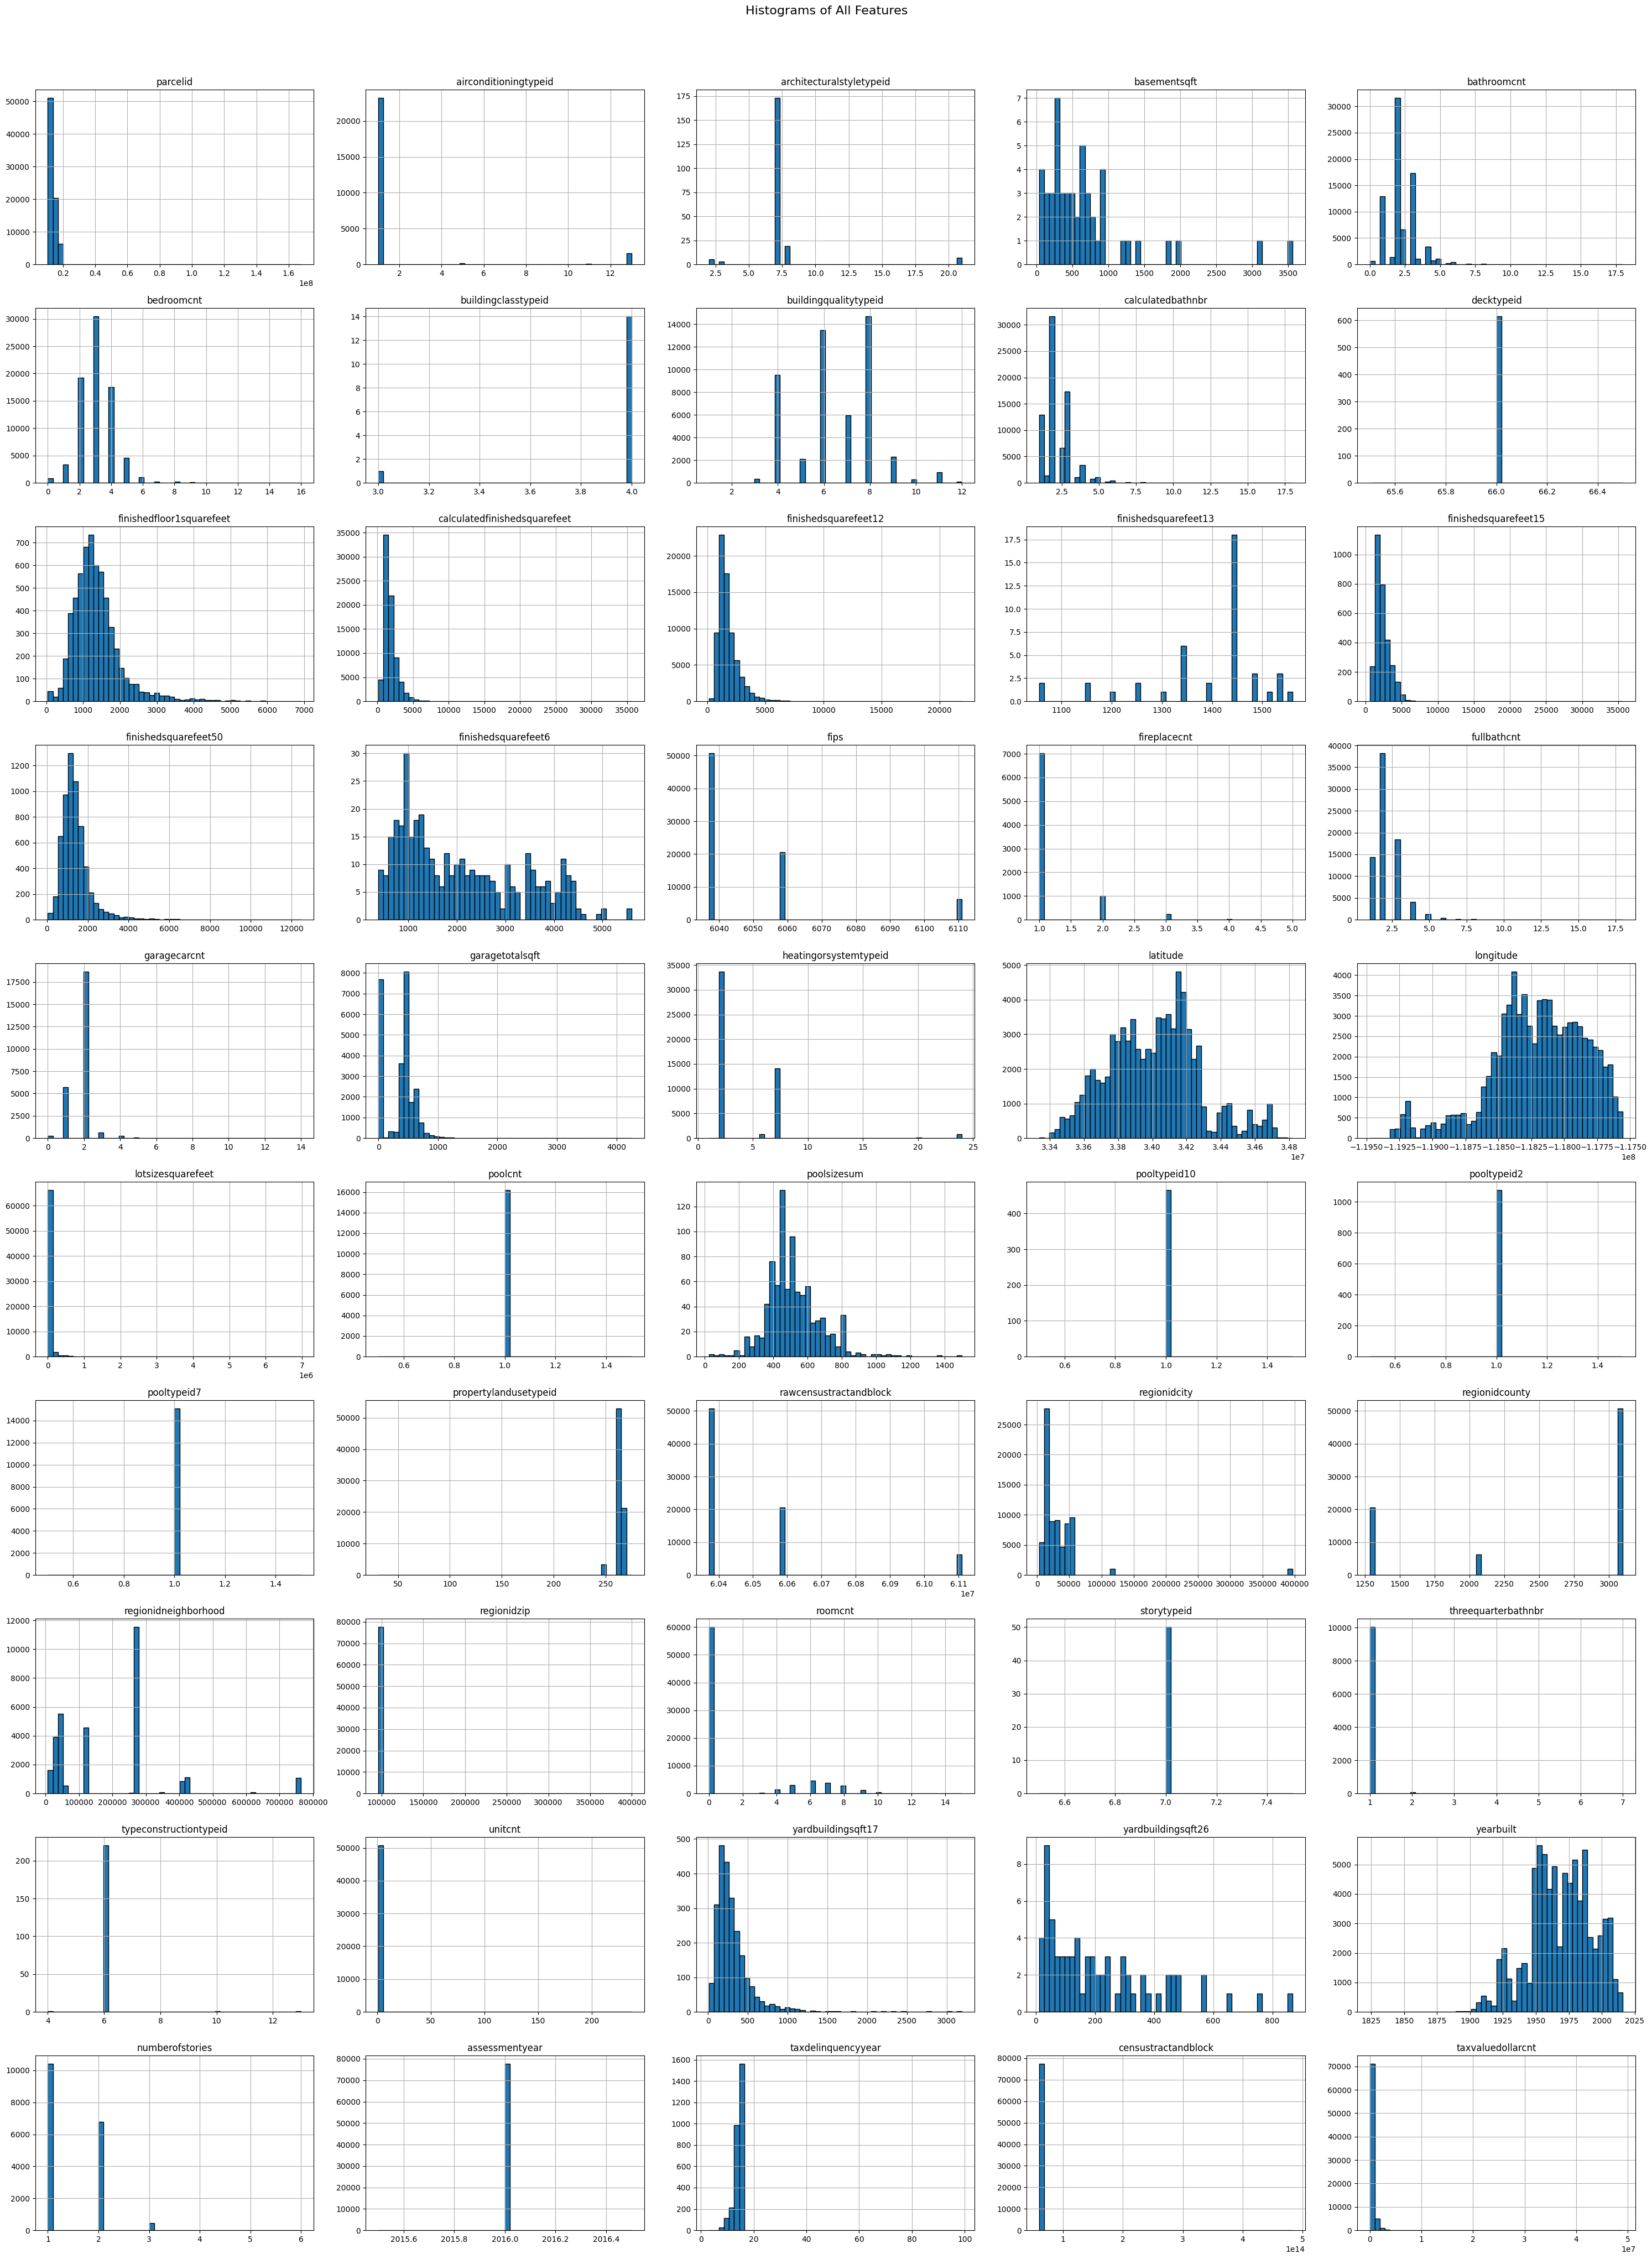

In [ ]:
# Overview histograms for all numerical features
df.hist(figsize=(30, 40), layout=(-1, 5), bins=50, edgecolor='black')
plt.suptitle("Histograms of All Features", fontsize=16, y=1.02)
plt.tight_layout()


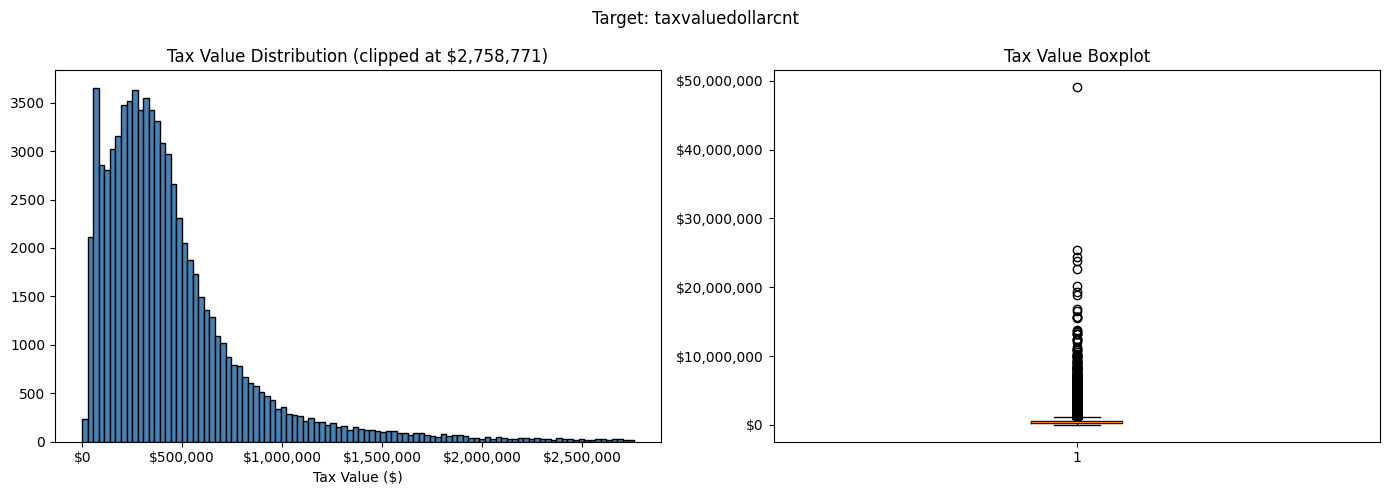

In [ ]:
# 1. TARGET: taxvaluedollarcnt - clipped histogram + boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data = df['taxvaluedollarcnt'].dropna()
upper = data.quantile(0.99)  # clip at 99th percentile to ease visualization

axes[0].hist(data[data <= upper], bins=100, edgecolor='black', color='steelblue')
axes[0].set_title(f'Tax Value Distribution (clipped at {dollar_format(upper, None)})')
axes[0].set_xlabel('Tax Value ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

axes[1].boxplot(data)
axes[1].set_title('Tax Value Boxplot')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

plt.suptitle('Target: taxvaluedollarcnt')
plt.tight_layout()

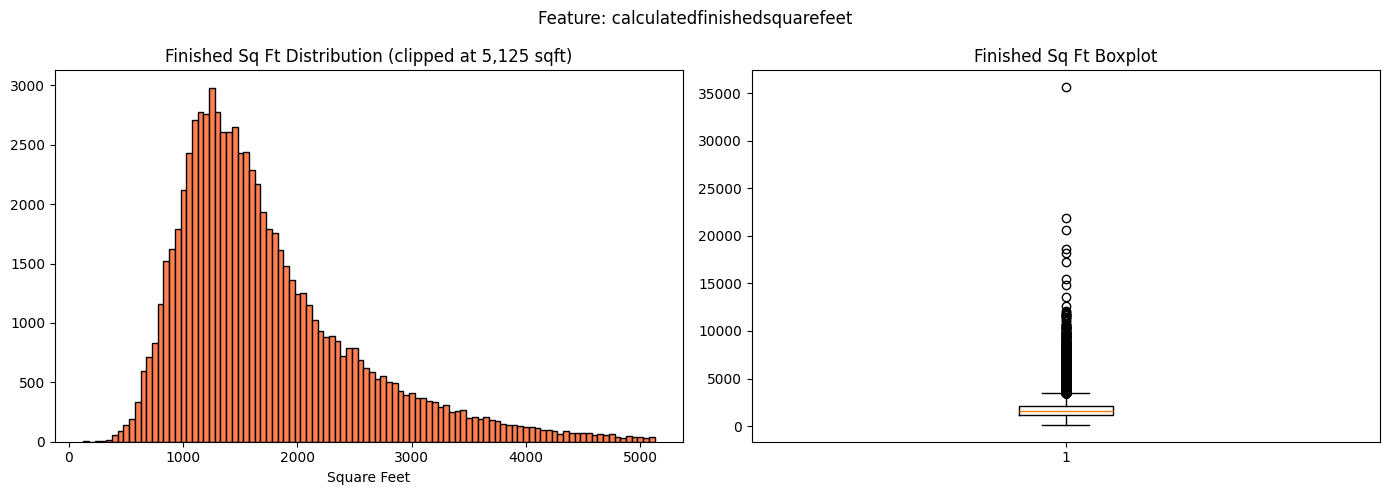

In [ ]:
# 2. calculatedfinishedsquarefeet - clipped histogram + boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data_sqft = df['calculatedfinishedsquarefeet'].dropna()
upper_sqft = data_sqft.quantile(0.99)

axes[0].hist(data_sqft[data_sqft <= upper_sqft], bins=100, edgecolor='black', color='coral')
axes[0].set_title(f'Finished Sq Ft Distribution (clipped at {upper_sqft:,.0f} sqft)')
axes[0].set_xlabel('Square Feet')

axes[1].boxplot(data_sqft)
axes[1].set_title('Finished Sq Ft Boxplot')

plt.suptitle('Feature: calculatedfinishedsquarefeet')
plt.tight_layout()

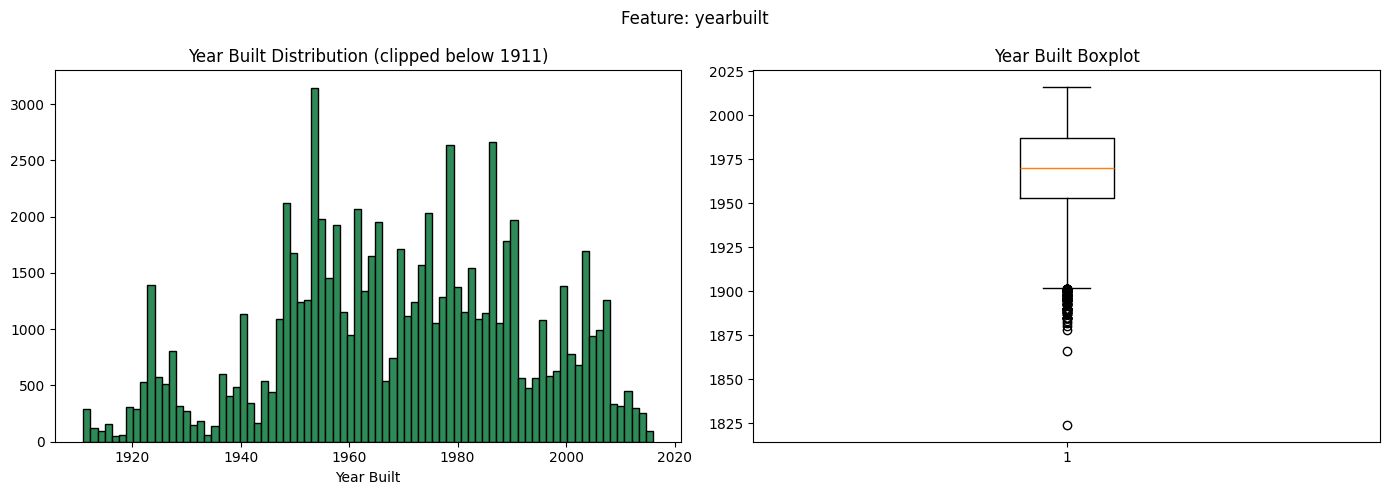

In [ ]:
# 3. yearbuilt - clipped histogram + boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data_year = df['yearbuilt'].dropna()
lower_year = data_year.quantile(0.01)

axes[0].hist(data_year[data_year >= lower_year], bins=80, edgecolor='black', color='seagreen')
axes[0].set_title(f'Year Built Distribution (clipped below {lower_year:.0f})')
axes[0].set_xlabel('Year Built')

axes[1].boxplot(data_year)
axes[1].set_title('Year Built Boxplot')

plt.suptitle('Feature: yearbuilt')
plt.tight_layout()

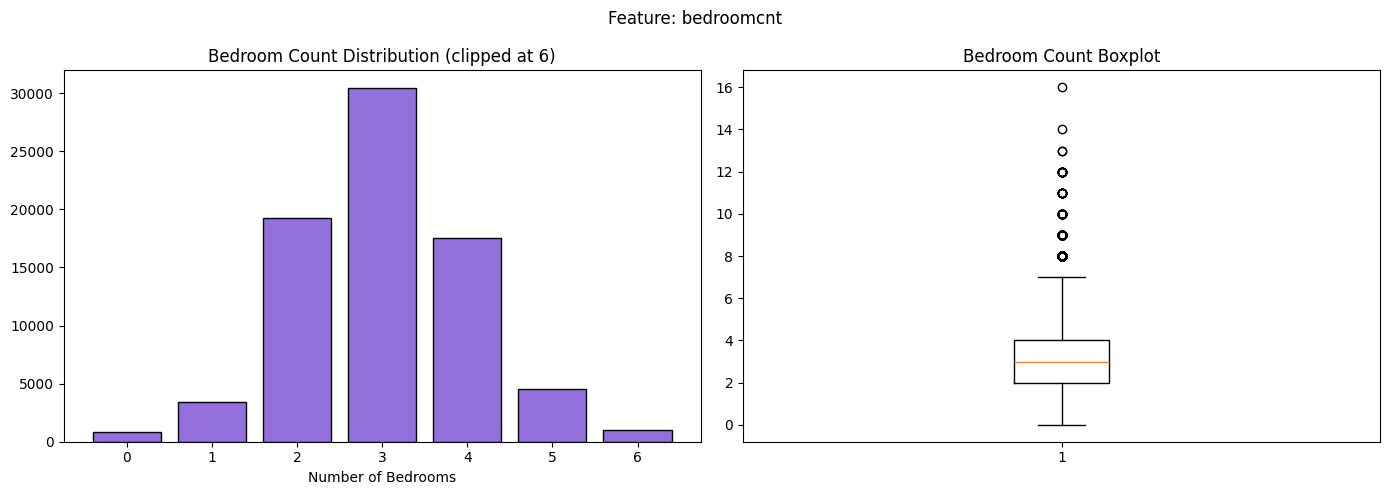

In [ ]:
# 4. bedroomcnt - clipped bar plot (discrete) + boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data_bed = df['bedroomcnt'].dropna()
upper_bed = data_bed.quantile(0.99)
bedroom_counts = data_bed[data_bed <= upper_bed].value_counts().sort_index()

axes[0].bar(bedroom_counts.index, bedroom_counts.values, edgecolor='black', color='mediumpurple')
axes[0].set_title(f'Bedroom Count Distribution (clipped at {upper_bed:.0f})')
axes[0].set_xlabel('Number of Bedrooms')

axes[1].boxplot(data_bed)
axes[1].set_title('Bedroom Count Boxplot')

plt.suptitle('Feature: bedroomcnt')
plt.tight_layout()

#### **2.B Discussion:** Describe in a paragraph what you learned in your detailed examination of the features you explored:
- What is the distribution (normal, exponential, etc.) if any?
- Any problems (e.g., outliers, any odd characteristics)?
- Anything else interesting? Why did you choose it?


The three features explored here are `calculatedfinishedsquarefeet`, `yearbuilt` and `bedroomcnt`. These are universally three of the strongest predictors of property value.

Each of the three contain extreme outliers that distorted the distributions and made interpretation difficult. For example, the initial bar chart of `calculatedfinishedsquarefeet` had a peak on the left and then nothing for the rest of the x axis, whereas `yearbuilt` had extremely old buildings as outliers, on the left of the chart.

To fix this, the outliers were clipped out of the charts. The top 1% for `calculatedfinishedsquarefeet` and `bedroomcnt` were excluded and the bottom 1% for 'yearbuilt'.

After generating better looking graphs, we can see that `calculatedfinishedsquarefeet` follows a standard right-skewed distribution, with a peak around 1300 square feet. `yearbuilt` doesn't follow a standard distribution type, except for a huge spike corresponding with post-WW2 home building efforts. There is an expected decline in homes older than that, with a higher frequency of homes being built in later years. For `bedroomcnt`, we are only looking at values between 0 and 6, which approximate a normal distribution centered on 3, but there aren't enough x values to categorize it as normal.

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task!

In [ ]:
drop_columns = ['parcelid','calculatedbathnbr','assessmentyear','censustractandblock','rawcensustractandblock']
df3a = df.drop(columns = drop_columns)

print(df3a.shape)

(77613, 50)


#### **3.A Discussion:** Justify in a paragraph your decisions about which features to drop.


Several columns were found to be unsuitable for regression testing. The `parcelid` variable was dropped because it is a unique identifier and has no predictive value. Additionally, `assessmentyear` is 2016 across most rows, and `censustractandblock` and its raw duplicate appear to be geographic identifiers stored as floats, and wouldn’t be suitable continuous measures for prediction. Finally, `calculatedbathnbr` was dropped because in many rows its values were identical to `bathroomcnt`.



### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully.

In [ ]:
# 70% threshold for dropping columns with too many missing values
df3b = df3a.dropna(axis=1, thresh=int(0.3 * len(df3a)))

print(df3b.shape)
print(df3b.columns)


(77613, 25)
Index(['airconditioningtypeid', 'bathroomcnt', 'bedroomcnt',
       'buildingqualitytypeid', 'calculatedfinishedsquarefeet',
       'finishedsquarefeet12', 'fips', 'fullbathcnt', 'garagecarcnt',
       'garagetotalsqft', 'heatingorsystemtypeid', 'latitude', 'longitude',
       'lotsizesquarefeet', 'propertycountylandusecode',
       'propertylandusetypeid', 'propertyzoningdesc', 'regionidcity',
       'regionidcounty', 'regionidneighborhood', 'regionidzip', 'roomcnt',
       'unitcnt', 'yearbuilt', 'taxvaluedollarcnt'],
      dtype='object')


#### **3.B Discussion:** In a paragraph, explain your decision about which features were dropped



Features missing more than 70% of their values were dropped. This threshold captures the columns identified in Part 2A, such as `storytypeid`, `architecturalstyletypeid`, and `buildingclasstypeid` which had 99%+ missing values with very few unique entries among the other values present. A 70% cutoff was chosen rather than a lower threshold to retain features like `poolcnt` and `airconditioningtypeid` that may carry significant data about property value.

### Part 3.C: Drop Problematic **samples**

There could be several reasons why you might want to drop a sample:
- It has  "too many" null values
- It has a null value in the target
- It contains outliers, especially in the target



Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [ ]:
# Drop samples where target value (`taxvaluedollarcnt`) is null
df3c = df3b.dropna(subset = ['taxvaluedollarcnt'])

# Drop samples with too many (over 50%) null values
df3c = df3c.dropna(thresh=int(0.5 * df3c.shape[1]))

# Drop samples with outliers in target
Q1, Q3 = df3c['taxvaluedollarcnt'].quantile([0.25, 0.75])
IQR = Q3 - Q1

lower = Q1 - 3 * IQR
upper = Q3 + 3 * IQR

df3c = df3c[(df3c['taxvaluedollarcnt'] >= lower) & (df3c['taxvaluedollarcnt'] <= upper)]

print(df3c.shape)

(75224, 25)


#### **3.C Discussion:** In a short paragraph, explain your decision about which samples were dropped


Samples were dropped for three reasons. First, rows where the target `taxvaluedollarcnt` was null were removed, because they are not suitable for regression training. Second, rows missing more than 50% of their remaining features were dropped, since imputing that many values per row would create noise. Finally, extreme outliers in the target were removed, the boxplot from Part 2B showed the target is heavily right-skewed which could distort model training.

### Part 3.D: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Answer the discussion question.

In [ ]:
df3d = df3c.copy()

# List of categorical columns
categorical_cols = df3d.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", categorical_cols)

# List of numerical columns
numerical_cols = df3d.select_dtypes(exclude=['object']).columns.tolist()
print("Numerical columns:", numerical_cols)

Categorical columns: ['propertycountylandusecode', 'propertyzoningdesc']
Numerical columns: ['airconditioningtypeid', 'bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'fips', 'fullbathcnt', 'garagecarcnt', 'garagetotalsqft', 'heatingorsystemtypeid', 'latitude', 'longitude', 'lotsizesquarefeet', 'propertylandusetypeid', 'regionidcity', 'regionidcounty', 'regionidneighborhood', 'regionidzip', 'roomcnt', 'unitcnt', 'yearbuilt', 'taxvaluedollarcnt']


In [ ]:
# Constant value imputation for binary features
binary_cols = [col for col in df3d.columns if df3d[col].nunique() <= 2]
df3d[binary_cols] = df3d[binary_cols].fillna(0)

# Median imputation for numerical features
remaining_num = [c for c in numerical_cols if c not in binary_cols]
for col in remaining_num:
    df3d[col] = df3d[col].fillna(df3d[col].median())

# Mode imputation for categorical features
for col in categorical_cols:
    df3d[col] = df3d[col].fillna(df3d[col].mode().iloc[0])

print("Remaining null values:", df3d.isnull().values.sum())

Remaining null values: 0


#### **3.D Discussion:**  Describe in a paragraph your decisions about which methods you used to impute missing values in the dataset


Three imputation strategies were used depending on the nature of each feature. Binary features were filled with 0, since a missing value most likely means the property does not have that feature. The remaining numeric features were imputed with the median, since many have right-skewed distributions. Categorical features were filled with the mode as a neutral default.


### 3.E: Encode the Categorical Features (if any)

You may not have any categorical features. If you do, encode them in the next step. No discussion is necessary.

## Part 4:  Investigate Feature Relationships  [6 pts]

In this part, we will investigate the feature relationships as a way of understanding the data.  In the next part, we'll investigate potential feature engineering opportunities.

**Note:**  We won't be committing to any changes to the data until Milestone 2, as our choice of transformations will very much depend on the model we're building. But investigating these aspects of the data is an essential step in the first stages of our project.

### Part 4.A:

   - Compute and analyze pairwise correlations using a correlation matrix.
   - Compute the F-statistic for all features for a better view of the relationships (displaying them in a bar chart would be useful as well).
   - Identify features with strong correlations or notable relationships that may impact model performance.
   - Investigate forward and backward feature selection
        - Run these algorithms to investigate possible feature selection (don't commit to any selections yet)

Your code below, in multiple cells with descriptive comments.

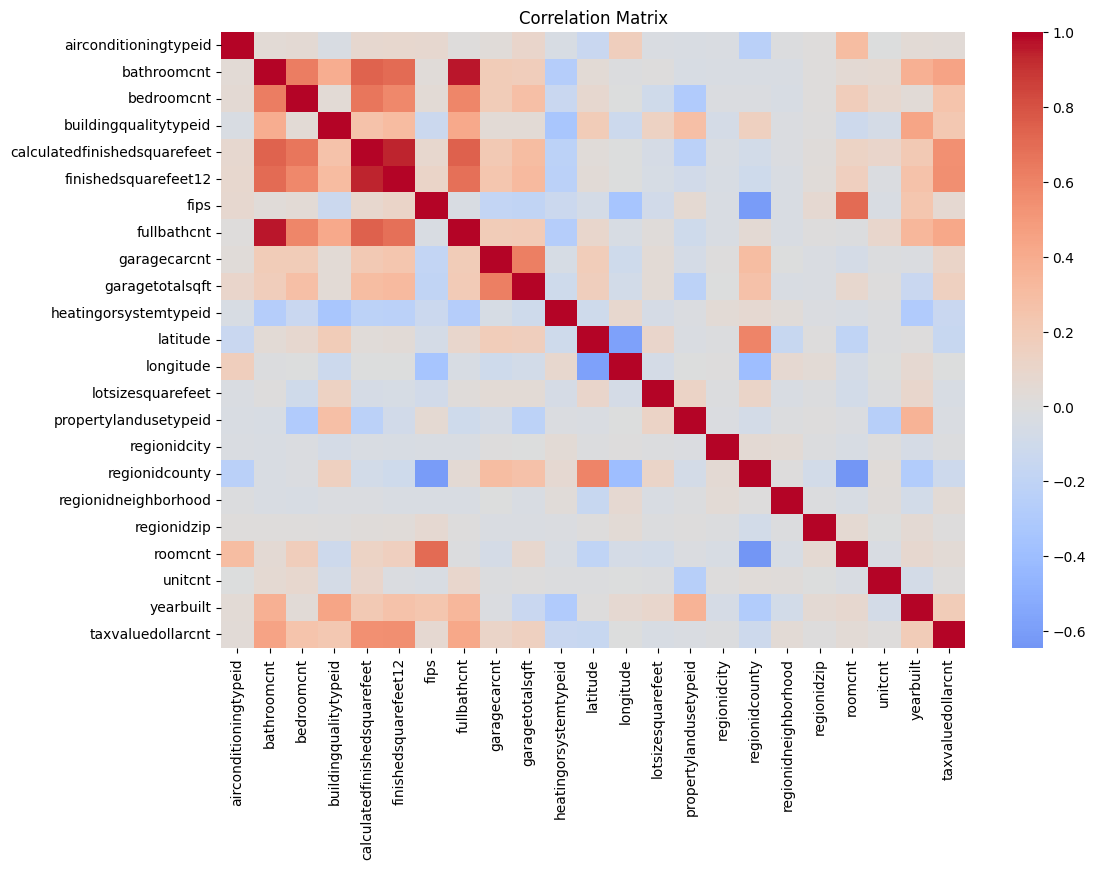

In [ ]:
# Correlation matrix (numerical features only)
corr_matrix = df3d.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
target_corr = corr_matrix['taxvaluedollarcnt'].sort_values(ascending=False)
print(target_corr.head(10))

taxvaluedollarcnt               1.000000
finishedsquarefeet12            0.545563
calculatedfinishedsquarefeet    0.538660
bathroomcnt                     0.441325
fullbathcnt                     0.427061
bedroomcnt                      0.251378
buildingqualitytypeid           0.227950
yearbuilt                       0.194205
garagetotalsqft                 0.147757
garagecarcnt                    0.119695
Name: taxvaluedollarcnt, dtype: float64


In [ ]:
# Separate features and target
X = df3d.drop(columns=['taxvaluedollarcnt'])
y = df3d['taxvaluedollarcnt']

# Keep only numeric features for F-test
X_numeric = X.select_dtypes(include=['int64', 'float64'])

# Compute F-statistic
f_values, p_values = f_regression(X_numeric, y)

# Store results
f_df = pd.DataFrame({
    'Feature': X_numeric.columns,
    'F-Score': f_values,
    'p-value': p_values
}).sort_values(by='F-Score', ascending=False)

print(f_df.head(10))

                         Feature       F-Score  p-value
5           finishedsquarefeet12  31876.806857      0.0
4   calculatedfinishedsquarefeet  30747.535638      0.0
1                    bathroomcnt  18194.496106      0.0
7                    fullbathcnt  16779.341650      0.0
2                     bedroomcnt   5073.987364      0.0
3          buildingqualitytypeid   4122.859374      0.0
21                     yearbuilt   2948.243905      0.0
11                      latitude   1859.499058      0.0
9                garagetotalsqft   1678.902056      0.0
10         heatingorsystemtypeid   1627.224577      0.0


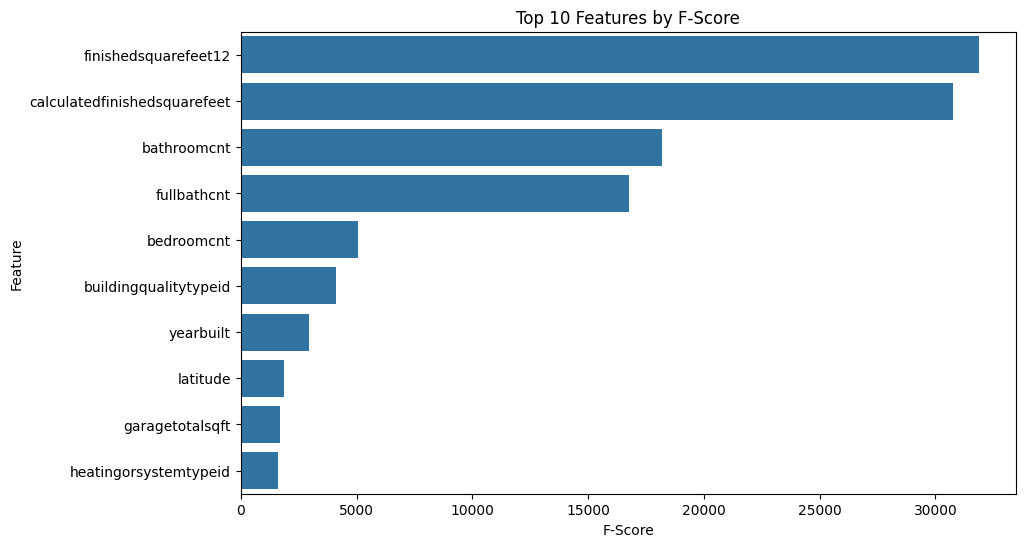

In [ ]:
# Bar Chart Visualization of top 10 features by F-score
plt.figure(figsize=(10, 6))
sns.barplot(x='F-Score', y='Feature', data=f_df.head(10))
plt.title("Top 10 Features by F-Score")
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
# Forward Feature Selection
model = LinearRegression()

forward_selector = SequentialFeatureSelector(
    model,
    n_features_to_select=5,
    direction='forward'
)

forward_selector.fit(X_numeric, y)

forward_features = X_numeric.columns[forward_selector.get_support()]
print("Forward Selected Features:", list(forward_features))

Forward Selected Features: ['bathroomcnt', 'finishedsquarefeet12', 'latitude', 'longitude', 'roomcnt']


In [ ]:
# Backward Feature Selection
backward_selector = SequentialFeatureSelector(
    model,
    n_features_to_select=5,
    direction='backward'
)

backward_selector.fit(X_numeric, y)

backward_features = X_numeric.columns[backward_selector.get_support()]
print("Backward Selected Features:", list(backward_features))

Backward Selected Features: ['bathroomcnt', 'finishedsquarefeet12', 'latitude', 'longitude', 'roomcnt']


#### **4.A Discussion:**  Describe in a paragraph what you see in the feature relationships and correlations.

Pay particular attention to especially interesting and/or strongly correlated feature relationships.
 How do the different methods for seeing relationships compare? Do they agree or disagree?



A correlation matrix was used to examine pairwise relationships between numerical features and the target variable `taxvaluedollarcnt`. The strongest positive correlations were observed with `finishedsquarefeet12` and `calculatedfinishedsquarefeet`, indicating that property size is a major driver of property value. Additional moderately strong correlations were found with `bathroomcnt` and `fullbathcnt`, further supporting the importance of structural property features.

The correlation matrix also revealed high correlations between certain features, such as `finishedsquarefeet12` and `calculatedfinishedsquarefeet`, as well as `bathroomcnt` and `fullbathcnt`. This suggests the presence of multicollinearity, meaning some features may be redundant and could impact model stability if not addressed in later stages.

The F-statistic analysis reinforced these findings, with `finishedsquarefeet12` and `calculatedfinishedsquarefeet` achieving the highest F-scores, followed by `bathroomcnt` and `fullbathcnt`. These results confirm that features related to property size and layout have the strongest relationships with the target variable. Additionally, geographic features such as `latitude` also showed notable importance, suggesting that location plays a meaningful role in property valuation.

Forward and backward feature selection methods were applied to further explore feature importance. Both methods consistently selected the same subset of features: `bathroomcnt`, `finishedsquarefeet12`, `latitude`, `longitude`, and `roomcnt`. This consistency strengthens confidence in these variables as key predictors of property value. These findings will inform future feature selection and engineering decisions in subsequent stages of the project.

### Part 4.B:  2-Dimensional Visualizations for Interesting Patterns  
   - Select three (3) pairs of features that exhibit meaningful relationships based on your previous analysis.
   - Create 2D scatter plots or density plots to explore interactions between these features.  
   - Provide brief interpretations of any observed patterns or trends.

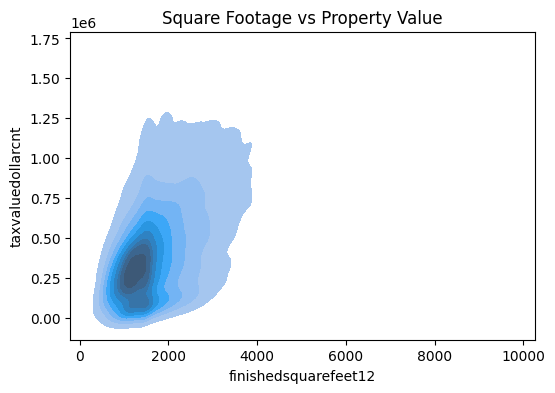

In [ ]:
# Square Footage vs Property Value Plot
plt.figure(figsize=(6,4))
sns.kdeplot(
    x='finishedsquarefeet12',
    y='taxvaluedollarcnt',
    data=df3d,
    fill=True
)
plt.title("Square Footage vs Property Value")
plt.show()

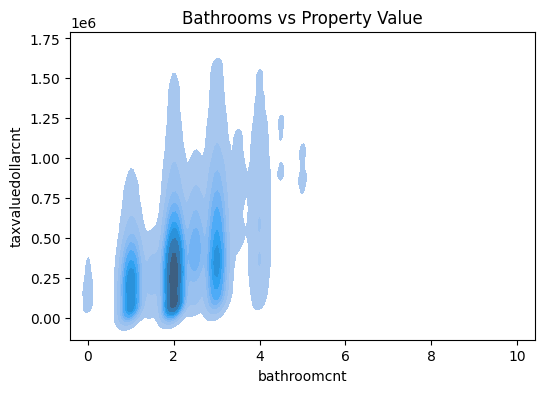

In [ ]:
# Bathrooms vs Property Value Plot
plt.figure(figsize=(6,4))
sns.kdeplot(
    x='bathroomcnt',
    y='taxvaluedollarcnt',
    data=df3d,
    fill=True
)
plt.title("Bathrooms vs Property Value")
plt.show()

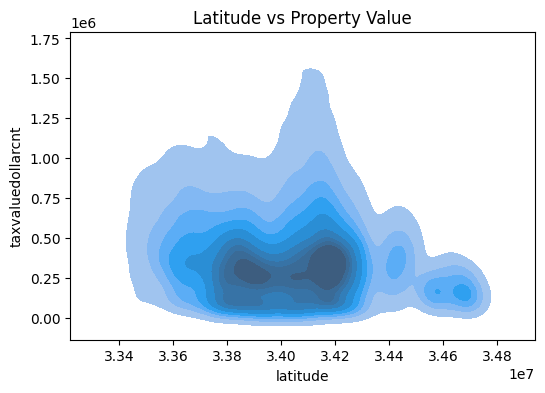

In [ ]:
# Latitude vs Property Value Plot
plt.figure(figsize=(6,4))
sns.kdeplot(
    x='latitude',
    y='taxvaluedollarcnt',
    data=df3d,
    fill=True
)
plt.title("Latitude vs Property Value")
plt.show()

#### **4.B Discussion:** Provide brief interpretations of any observed patterns or trends.


Three feature pairs were selected to explore meaningful relationships with the target variable `taxvaluedollarcnt`. The relationship between `finishedsquarefeet12` and property value shows a clear positive trend, where larger homes are generally associated with higher values. The density plot highlights a strong concentration of properties between approximately 1000 and 2500 square feet, with values increasing as square footage increases. Additionally, the spread widens at higher square footage levels, indicating greater variability in high-value homes.

The relationship between `bathroomcnt` and property value also demonstrates a positive trend. Properties with more bathrooms tend to have higher values, with clear density clusters around common bathroom counts such as 2 and 3. The discrete vertical banding reflects the categorical nature of this feature, while the upward shift in density with increasing bathroom count reinforces its importance as a predictor.

The relationship between `latitude` and property value reveals geographic variation in housing prices. While the pattern is less strictly linear, certain latitude ranges show higher concentrations of high-value properties, particularly around the central latitude bands in the dataset. This suggests that location plays a significant role in property valuation, likely capturing underlying neighborhood and regional differences.

Overall, these visualizations confirm earlier findings that property size, structural characteristics, and geographic location are key drivers of property value.

## Part 5:  Feature Engineering: Investigate various transformations to better expose the underlying data patterns to machine learning algorithms. [6 pts]

**Important Notes:**  
- This last part is a bit open ended, since there is a huge variety of feature engineering techniques, most of which won't be useful for your particular dataset.
- Understand that you can't evaluate the final usefulness of these transformations
until you choose a model, and  models may respond differently to various transformations or obviate some transformations (e.g., ensemble methods already do feature selection).
- Therefore, write your transformations as functions or otherwise be prepared
to choose later on which transformations may be necessary.

**Investigate feature engineering, where appropriate:**

- Feature scaling: standardize or normalize features as necessary
- Decompose features (e.g., categorical into One-Hot feature sequence, date/time into two features data and time, etc.).
- Add promising transformations of features
    - Exponential $\exp(x_i)$ or logarithmic $\log(x_j)$
    - Polynomial features  ( $x_i^2$, $x_i - x_j$), products ($x_i*x_j$), or ratios ($x_i/x_j$)

**ToDo:**
- Pick at least three transformations to try.
- Try each one and evaluate its effect using correlations or F-scores or a feature selection algorithm.
- Answer the discussion question.

### Transformation 1: Log Transformation

In [ ]:
df5 = df3d.copy()

# Log transform target (common in housing data)
df5['log_taxvalue'] = np.log1p(df5['taxvaluedollarcnt'])

# Log transform size feature
df5['log_sqft'] = np.log1p(df5['finishedsquarefeet12'])

# Compare correlation before vs after
print("Original:", df3d['finishedsquarefeet12'].corr(df3d['taxvaluedollarcnt']))
print("Log Transformed:", df5['log_sqft'].corr(df5['log_taxvalue']))

Original: 0.5455632265862495
Log Transformed: 0.4523842025820208


### Transformation 2: Feature Interactions

In [ ]:
# Interaction features
df5['sqft_per_room'] = df5['finishedsquarefeet12'] / (df5['roomcnt'] + 1)
df5['bath_per_bed'] = df5['bathroomcnt'] / (df5['bedroomcnt'] + 1)

print(df5[['sqft_per_room', 'bath_per_bed', 'log_taxvalue']].corr())

               sqft_per_room  bath_per_bed  log_taxvalue
sqft_per_room       1.000000      0.273660      0.290946
bath_per_bed        0.273660      1.000000      0.299555
log_taxvalue        0.290946      0.299555      1.000000


### Transformation 3: Feature Scaling

In [ ]:
# Feature Scaling
scaler = StandardScaler()

scale_cols = ['finishedsquarefeet12', 'bathroomcnt', 'latitude', 'longitude']

df5_scaled = df5.copy()
df5_scaled[scale_cols] = scaler.fit_transform(df5[scale_cols])

# Re-evaluate F-Score
X_scaled = df5_scaled[scale_cols]
y = df5_scaled['taxvaluedollarcnt']

f_vals, _ = f_regression(X_scaled, y)

print(pd.DataFrame({
    'Feature': scale_cols,
    'F-Score': f_vals
}).sort_values(by='F-Score', ascending=False))

                Feature       F-Score
0  finishedsquarefeet12  31876.806857
1           bathroomcnt  18194.496106
2              latitude   1859.499059
3             longitude      1.903769


#### **5 Discussion:** Describe in a paragraph why you chose these transformations and what you observed.


The selected transformations were chosen to address common issues in real world datasets, including skewness, feature interactions, and differences in scale. Logarithmic transformations were applied to reduce skewness in key variables, but they did not improve correlations, suggesting the original features already captured the relationships effectively. Interaction features were introduced to explore whether combining variables could reveal additional patterns, but they showed weaker relationships than the original features. Feature scaling was applied to standardize ranges, which did not affect feature importance but remains important for certain models. Overall, these transformations provided insight into the data but did not significantly enhance predictive relationships at this stage.

## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |

